# TP4 -  Forêt d’arbres aléatoires
### Sharaine MALARVIJY 21206543

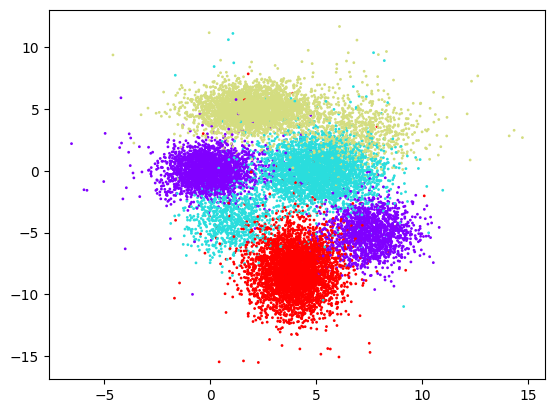

In [253]:
import numpy as np
import matplotlib.pyplot as plt
import time as t
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV

def visualize_classifier(model, X, y):
    ax = plt.gca()
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=1, cmap='rainbow',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    # Create a color plot with the results

    n_classes = len(np.unique(y))
    plt.scatter(xx.ravel(), yy.ravel(), c=Z, s=0.1, cmap='rainbow');
    ax.set(xlim=xlim, ylim=ylim)
    plt.show()
    
data = np.load("TP4.npz")
X_train, y_train, X_test, y_test = (data[key] for key in ["X_train", "y_train", "X_test", "y_test"])


plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=1, cmap='rainbow');
plt.show()  

## I. Chargement et visualisation des données

In [254]:
print(f"Il y a {X_train.shape[0]} points dans la base d’apprentissage")
print(f"Il y a {X_test.shape[0]} points dans la base d’apprentissage")

print(f"La dimension des données sont de {X_train.shape} pour la base d’apprentissage")
print(f"La dimension des données sont de {X_test.shape} pour la base d’test")

Il y a 16640 points dans la base d’apprentissage
Il y a 4160 points dans la base d’apprentissage
La dimension des données sont de (16640, 2) pour la base d’apprentissage
La dimension des données sont de (4160, 2) pour la base d’test


## II. Arbre de décision 
### a. Principe des arbres de décision

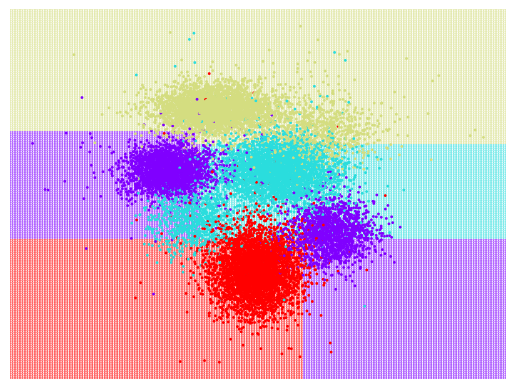

In [255]:
tree1 = tree.DecisionTreeClassifier(criterion='entropy', max_depth = 3, random_state= 543) 
tree1.fit(X_train, y_train)
visualize_classifier(tree1, X_train, y_train) 

La variable max_depth represente la profondeur maximal d'une branche de l'arbre.

On observe des points dont les couleurs correspondent leurs classes et sur le graph des zone de couleurs où les zones correspondent au classes predite par le classifieur.

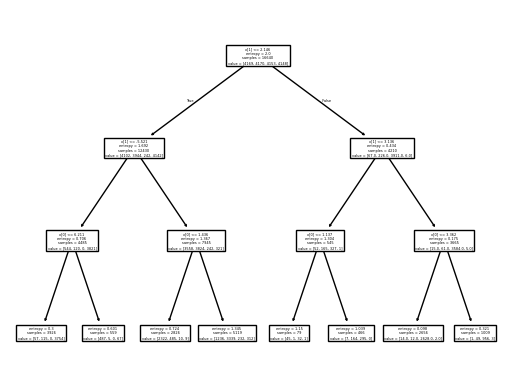

In [256]:
tree.plot_tree(tree1) 
plt.show() 

In [257]:
text_representation = tree.export_text(tree1) 
print(text_representation)

|--- feature_1 <= 2.15
|   |--- feature_1 <= -5.52
|   |   |--- feature_0 <= 6.21
|   |   |   |--- class: 4.0
|   |   |--- feature_0 >  6.21
|   |   |   |--- class: 1.0
|   |--- feature_1 >  -5.52
|   |   |--- feature_0 <= 1.44
|   |   |   |--- class: 1.0
|   |   |--- feature_0 >  1.44
|   |   |   |--- class: 2.0
|--- feature_1 >  2.15
|   |--- feature_1 <= 3.14
|   |   |--- feature_0 <= 1.14
|   |   |   |--- class: 1.0
|   |   |--- feature_0 >  1.14
|   |   |   |--- class: 3.0
|   |--- feature_1 >  3.14
|   |   |--- feature_0 <= 3.36
|   |   |   |--- class: 3.0
|   |   |--- feature_0 >  3.36
|   |   |   |--- class: 3.0



On a la version écrite et en arbre du graph de visual_classfieur où on vois les condition de chaque zone pour des differentes classes.

### b. Performance d’un classifieur muti-classes

In [258]:
def precision(tn, fp, fn, tp):
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall(tn, fp, fn, tp):
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score(tn, fp, fn, tp):
    p = precision(tn, fp, fn, tp)
    r = recall(tn, fp, fn, tp)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


y_pred = tree1.predict(X_test) 
C = confusion_matrix(y_test, y_pred)

tp = C[0, 0]
fn = C[0, 1:].sum()
fp = C[1:, 0].sum()
total = C.sum()
tn = total - tp - fn - fp

print("Pour la classe 1 : ")
print("Précision :", round(precision(tn, fp, fn, tp), 2), "capacité du système à ne pas détecter de faux positifs")
print("Rappel    :", round(recall(tn, fp, fn, tp), 2), "capacité du systeme à détecter les positifs")
print("F1-score  :", round(f1_score(tn, fp, fn, tp), 2), "Combinaison de Precision et Rappel")
print("Support  :", y_test[y_test==1].size, "Nombre de d'exemple de classe 1")


print(classification_report(y_test, y_pred)) 
print('Accuracy=', accuracy_score(y_test, y_pred)) 

Pour la classe 1 : 
Précision : 0.83 capacité du système à ne pas détecter de faux positifs
Rappel    : 0.66 capacité du systeme à détecter les positifs
F1-score  : 0.73 Combinaison de Precision et Rappel
Support  : 1031 Nombre de d'exemple de classe 1
              precision    recall  f1-score   support

         1.0       0.83      0.66      0.73      1031
         2.0       0.64      0.79      0.71      1030
         3.0       0.93      0.94      0.94      1047
         4.0       0.96      0.91      0.93      1052

    accuracy                           0.83      4160
   macro avg       0.84      0.83      0.83      4160
weighted avg       0.84      0.83      0.83      4160

Accuracy= 0.8264423076923076


### c. Optimisation de la profondeur de l’arbre 

max_depth= 19


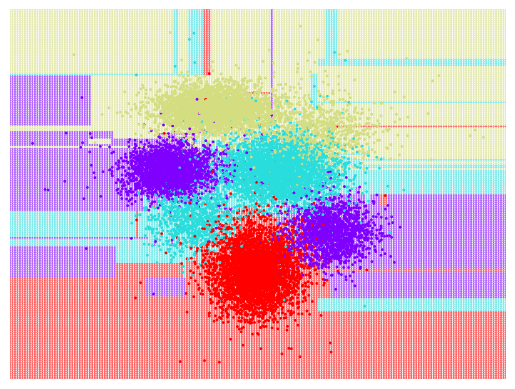

max_depth= 8


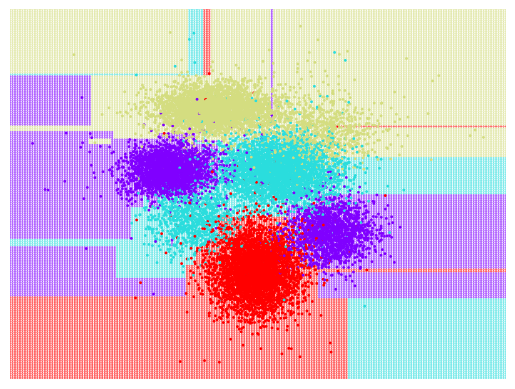

Accuracy maximal= 0.9300480769230769 pour un max_depth de 8


In [259]:
list_accuracy = []

for i in range(1, 20):
    tree1 = tree.DecisionTreeClassifier(criterion='entropy', max_depth = i, random_state= 543) 
    tree1.fit(X_train, y_train) 
    y_pred = tree1.predict(X_test)
    list_accuracy.append(accuracy_score(y_test, y_pred))

print("max_depth=", i)
visualize_classifier(tree1, X_train, y_train) 


max_depth_optimal = np.argmax(list_accuracy)+1
print("max_depth=", max_depth_optimal)

tree1 = tree.DecisionTreeClassifier(criterion='entropy', max_depth = max_depth_optimal, random_state= 543) 
tree1.fit(X_train, y_train) 
y_pred = tree1.predict(X_test)
visualize_classifier(tree1, X_train, y_train) 

print(f'Accuracy maximal= {np.max(list_accuracy)} pour un max_depth de {max_depth_optimal}') 

Visuellement on peut voir un la difference dans les graph quand max_depth = 19 ou 8. On voit plus de zone dans le premier graph dûe au sur-apprentissage sur les points isolées.

### d. Arbre de décision sur des données de grande dimension 

In [260]:
data = np.load("TP4b.npz")
X_train, y_train, X_test, y_test = (data[key] for key in ["X_train", "y_train", "X_test", "y_test"])

print(f"Il y a {X_train.shape[0]} points dans la base d’apprentissage")
print(f"Il y a {X_test.shape[0]} points dans la base d’apprentissage")

print(f"La dimension des données sont de {X_train.shape} pour la base d’apprentissage")
print(f"La dimension des données sont de {X_test.shape} pour la base d’test")

list_accuracy = []

for i in range(1, 20):
    tree1 = tree.DecisionTreeClassifier(criterion='entropy', max_depth = i, random_state= 543) 
    tree1.fit(X_train, y_train) 
    y_pred = tree1.predict(X_test)
    list_accuracy.append(accuracy_score(y_test, y_pred))

max_depth_optimal = np.argmax(list_accuracy)+1
print(f'Accuracy maximal= {np.max(list_accuracy)} pour un max_depth de {max_depth_optimal}') 

# tree1 = tree.DecisionTreeClassifier(criterion='entropy', max_depth = max_depth_optimal, random_state= 543) 
# tree1.fit(X_train, y_train) 
# y_pred = tree1.predict(X_test)
# print(f'Accuracy maximal= {accuracy_score(y_test, y_pred)} pour un max_depth de {max_depth_optimal}') 



Il y a 700 points dans la base d’apprentissage
Il y a 300 points dans la base d’apprentissage
La dimension des données sont de (700, 100) pour la base d’apprentissage
La dimension des données sont de (300, 100) pour la base d’test
Accuracy maximal= 0.31666666666666665 pour un max_depth de 7


# III. Forêt d’arbres aléatoires 
### a. Test d’une forêt d’arbres aléatoires

In [261]:
RF = RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=543) 
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)
print('Accuracy =', accuracy_score(y_test, y_pred))

Accuracy = 0.22


On peut voir que le taux de reconnaissance est médiocre à 10 arbres.

### b. Influence des paramètres

1 arbres donne 13.0% d'accuracy
61 arbres donne 35.0% d'accuracy
121 arbres donne 40.33% d'accuracy
181 arbres donne 42.0% d'accuracy
241 arbres donne 42.0% d'accuracy
301 arbres donne 43.33% d'accuracy
361 arbres donne 44.33% d'accuracy
421 arbres donne 44.33% d'accuracy
481 arbres donne 46.0% d'accuracy
541 arbres donne 45.0% d'accuracy
Accuracy maximal= 46.0% pour 481 arbre et un temps de calcul de 4.47s
L'accuracy commence à se stabilisé à partir de 200 environ donc on utilisera cette valeur pour minimiser le temps de calcul


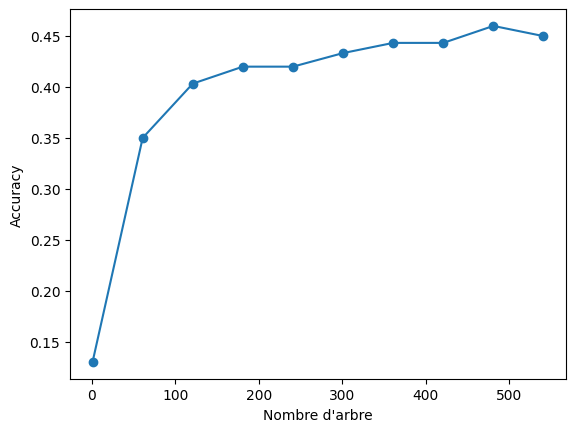

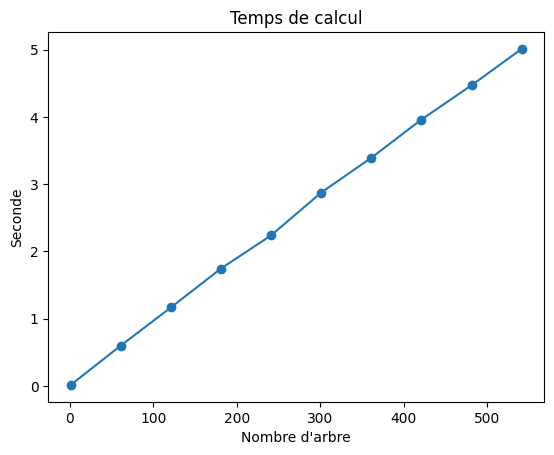

In [262]:
pas = 60 #On met un pas pour reduire le temps de calcul

list_nb_arbre = list(range(1, 600, pas))
list_accuracy = []
list_temps_calcul = []

for nb_arbre in list_nb_arbre:
    tps1 = t.time()

    RF = RandomForestClassifier(criterion='entropy', n_estimators=nb_arbre, random_state=543) 
    RF.fit(X_train, y_train)
    y_pred = RF.predict(X_test)

    tps2 = t.time()
    temps_calcul = tps2-tps1
    list_temps_calcul.append(temps_calcul)
    accuracy = accuracy_score(y_test, y_pred)
    list_accuracy.append(accuracy)
    print(f"{nb_arbre} arbres donne {round(accuracy*100, 2)}% d'accuracy")


plt.figure()
plt.plot(list_nb_arbre, list_accuracy, '-o')
plt.xlabel("Nombre d'arbre")
plt.ylabel("Accuracy")

plt.figure()
plt.plot(list_nb_arbre, list_temps_calcul, '-o')
plt.title("Temps de calcul")
plt.xlabel("Nombre d'arbre")
plt.ylabel("Seconde")

nb_arbre_optimal = np.argmax(list_accuracy)*pas+1
temps_calcul_pour_nb_arbre_optimal = list_temps_calcul[np.argmax(list_accuracy)]
print(f'Accuracy maximal= {round(np.max(list_accuracy)*100, 2)}% pour {nb_arbre_optimal} arbre et un temps de calcul de {round(temps_calcul_pour_nb_arbre_optimal, 2)}s') 

nb_arbre_optimal = 200
print(f"L'accuracy commence à se stabilisé à partir de {nb_arbre_optimal} environ donc on utilisera cette valeur pour minimiser le temps de calcul")


max_depth = 1, accuracy = 21.67%
max_depth = 3, accuracy = 33.0%
max_depth = 5, accuracy = 42.33%
max_depth = 7, accuracy = 43.67%
max_depth = 9, accuracy = 45.33%
max_depth = 11, accuracy = 45.0%
max_depth = 13, accuracy = 45.33%
max_depth = 15, accuracy = 44.33%
max_depth = 17, accuracy = 45.33%
max_depth = 19, accuracy = 45.33%
Accuracy maximal= 45.33% pour un max_depth de 9 et un temps de calcul de 3.76s


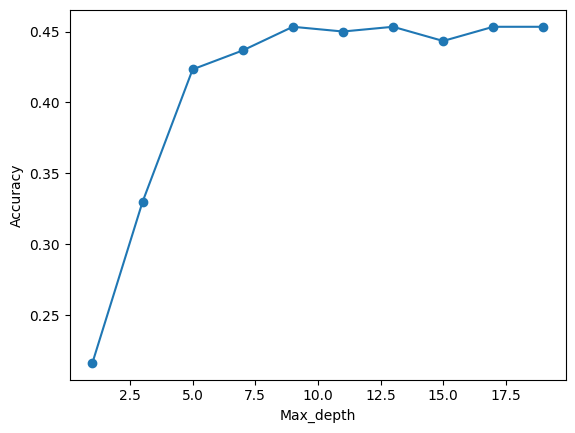

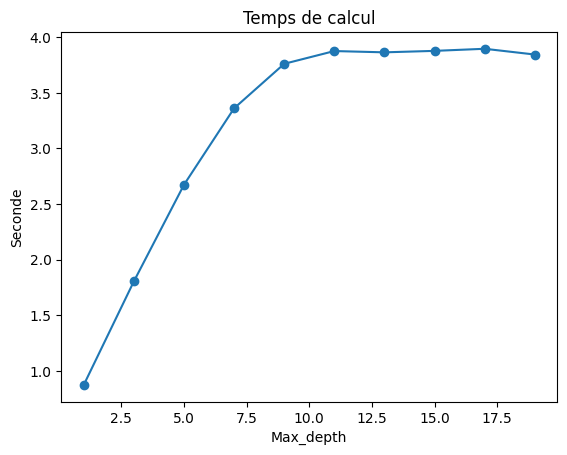

In [263]:
list_accuracy = []
list_temps_calcul = []

pas = 2
list_max_depth = list(range(1, 20, pas))
for md in list_max_depth:
    tps1 = t.time()

    RF = RandomForestClassifier(criterion='entropy', max_depth = md, n_estimators=400, random_state=543) 
    RF.fit(X_train, y_train)
    y_pred = RF.predict(X_test)
    list_accuracy.append(accuracy_score(y_test, y_pred))

    tps2 = t.time()
    temps_calcul = tps2-tps1
    list_temps_calcul.append(temps_calcul)
    print(f"max_depth = {md}, accuracy = {round(accuracy_score(y_test, y_pred)*100, 2)}%")



plt.figure()
plt.plot(list_max_depth, list_accuracy, '-o')
plt.xlabel("Max_depth")
plt.ylabel("Accuracy")

plt.figure()
plt.plot(list_max_depth, list_temps_calcul, '-o')
plt.title("Temps de calcul")
plt.xlabel("Max_depth")
plt.ylabel("Seconde")

max_depth_optimal = np.argmax(list_accuracy)*pas+1
temps_calcul_pour_nb_max_depth_optimal = list_temps_calcul[np.argmax(list_accuracy)]
print(f'Accuracy maximal= {round(np.max(list_accuracy)*100, 2)}% pour un max_depth de {max_depth_optimal} et un temps de calcul de {round(temps_calcul_pour_nb_max_depth_optimal, 2)}s') 

On peut voir que taux de reconnaissance stagne à partir d'un max_depth de 6 ce qui est environ le max_depth_optimal trouvée dans la partie II.b. du TP. De plus, grâce au RandomForestClassifier on n'a plus de probleme de sur-apprentissage.

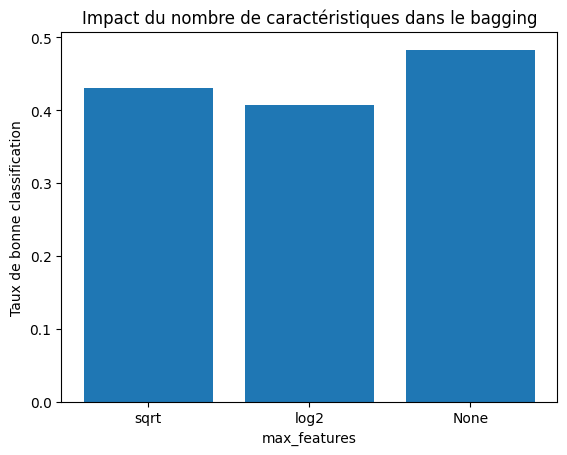

Accuracy avec les meilleurs paramètres choisi : 48.33%


In [264]:
features_options = ['sqrt', 'log2', None]
list_accuracy = []

for f in features_options:
    RF = RandomForestClassifier(n_estimators=nb_arbre_optimal, criterion='entropy', max_depth=max_depth_optimal, max_features=f, random_state=543)
    RF.fit(X_train, y_train)
    y_pred = RF.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    list_accuracy.append(acc)

plt.bar([str(f) for f in features_options], list_accuracy)
plt.xlabel("max_features")
plt.ylabel("Taux de bonne classification")
plt.title("Impact du nombre de caractéristiques dans le bagging")
plt.show()

print(f"Accuracy avec les meilleurs paramètres choisi : {round(max(list_accuracy)*100, 2)}%")

Ces évolutions sont prévisible car plus on  de paramètre plus l'accuracy augmente comme on n'a pas à gérer le sur-apprentissage grâce au RandomForestClassifier.

### c. Choix des paramètres optimaux

In [266]:
param_grid = {
    'n_estimators': [nb_arbre_optimal-50, nb_arbre_optimal],
    'max_depth': [max_depth_optimal-5, max_depth_optimal],
    'max_features': [None],
    'criterion': ['entropy'] 
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=543), param_grid=param_grid, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)

best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Taux de reconnaissance (après GridSearchCV) : {round(accuracy*100, 2)}%")

Meilleurs paramètres : {'criterion': 'entropy', 'max_depth': np.int64(9), 'max_features': None, 'n_estimators': 200}
Taux de reconnaissance (après GridSearchCV) : 48.33%


Le paramètre cv (cross-validation) indique le nombre de sous-ensembles dans lequel les données  seront diviser. 